# 🎲 Probabilidade de Eventos com o Censo Escolar 2023

Este notebook aplica conceitos de **probabilidade** utilizando o mesmo conjunto de dados do Censo Escolar 2023,
já utilizados na análise de estatística descritiva. As análises seguem o padrão profissional com base no PEP 8.

Serão trabalhados conceitos de:
- Eventos simples e compostos
- Probabilidade condicional
- Probabilidade de união e interseção
- Probabilidades por frequência relativa


In [1]:
# 📚 Importações
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
# 📥 Leitura completa dos dados (mesmo dataset do projeto 01)
caminho_arquivo = r"C:/Users/Usuario/Desktop/microdados_censo_escolar_2023/dados/microdados_ed_basica_2023.csv"
colunas_utilizadas = ["NO_REGIAO", "TP_LOCALIZACAO", "TP_DEPENDENCIA", "QT_MAT_BAS"]

df = pd.read_csv(
    caminho_arquivo,
    sep=";",
    encoding="latin1",
    usecols=colunas_utilizadas
)

df.rename(columns={
    "TP_LOCALIZACAO": "localizacao",
    "TP_DEPENDENCIA": "dependencia",
    "QT_MAT_BAS": "matriculas",
    "NO_REGIAO": "regiao"
}, inplace=True)

# Mapear códigos
df["localizacao"] = df["localizacao"].map({1: "Urbana", 2: "Rural"})
df["dependencia"] = df["dependencia"].map({1: "Federal", 2: "Estadual", 3: "Municipal", 4: "Privada"})

## 🎯 Probabilidade de Eventos Simples e Compostos

In [3]:
# Evento: escola localizada em área urbana
total = len(df)
urbana = len(df[df["localizacao"] == "Urbana"])
p_urbana = urbana / total
print(f"P(Urbana) = {p_urbana:.4f}")

P(Urbana) = 0.6624


In [4]:
# Evento: escola municipal e urbana (interseção)
evento_intersecao = df[(df["dependencia"] == "Municipal") & (df["localizacao"] == "Urbana")]
p_mun_e_urb = len(evento_intersecao) / total
print(f"P(Municipal ∩ Urbana) = {p_mun_e_urb:.4f}")

P(Municipal ∩ Urbana) = 0.2999


In [5]:
# Evento: escola municipal ou urbana (união)
evento_uniao = df[(df["dependencia"] == "Municipal") | (df["localizacao"] == "Urbana")]
p_mun_ou_urb = len(evento_uniao) / total
print(f"P(Municipal ∪ Urbana) = {p_mun_ou_urb:.4f}")

P(Municipal ∪ Urbana) = 0.9631


## 🎯 Probabilidade Condicional

In [6]:
# Probabilidade de a escola ser urbana dado que é privada
condicao = df[df["dependencia"] == "Privada"]
evento_cond = condicao[condicao["localizacao"] == "Urbana"]
p_urb_dado_priv = len(evento_cond) / len(condicao)
print(f"P(Urbana | Privada) = {p_urb_dado_priv:.4f}")

P(Urbana | Privada) = 0.9816


## 📊 Visualizações de Probabilidades

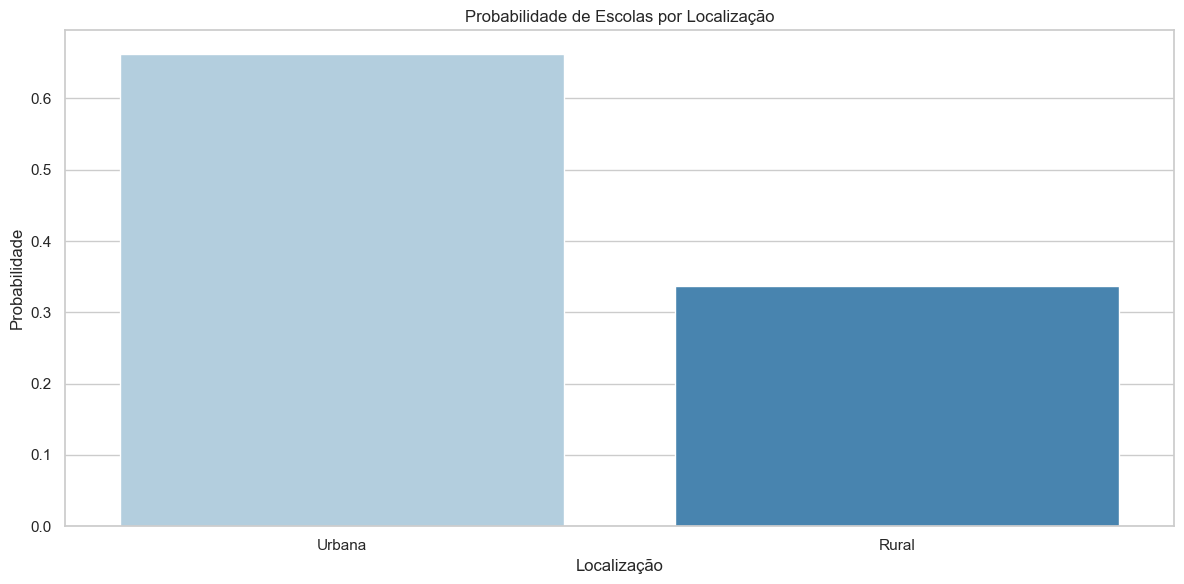

In [7]:
# 📊 Gráfico de barras: distribuição por localização
freq_loc = df['localizacao'].value_counts(normalize=True)
sns.barplot(x=freq_loc.index, y=freq_loc.values, palette='Blues')
plt.title('Probabilidade de Escolas por Localização')
plt.ylabel('Probabilidade')
plt.xlabel('Localização')
plt.tight_layout()
plt.show()

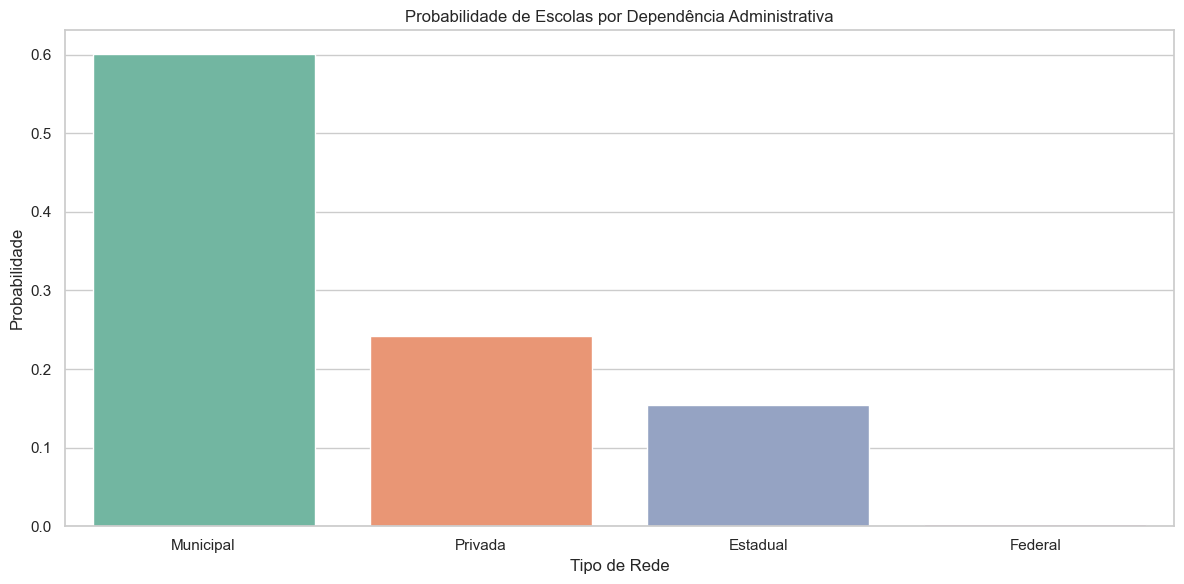

In [8]:
# 📊 Gráfico de barras: distribuição por tipo de dependência
freq_dep = df['dependencia'].value_counts(normalize=True)
sns.barplot(x=freq_dep.index, y=freq_dep.values, palette='Set2')
plt.title('Probabilidade de Escolas por Dependência Administrativa')
plt.ylabel('Probabilidade')
plt.xlabel('Tipo de Rede')
plt.tight_layout()
plt.show()

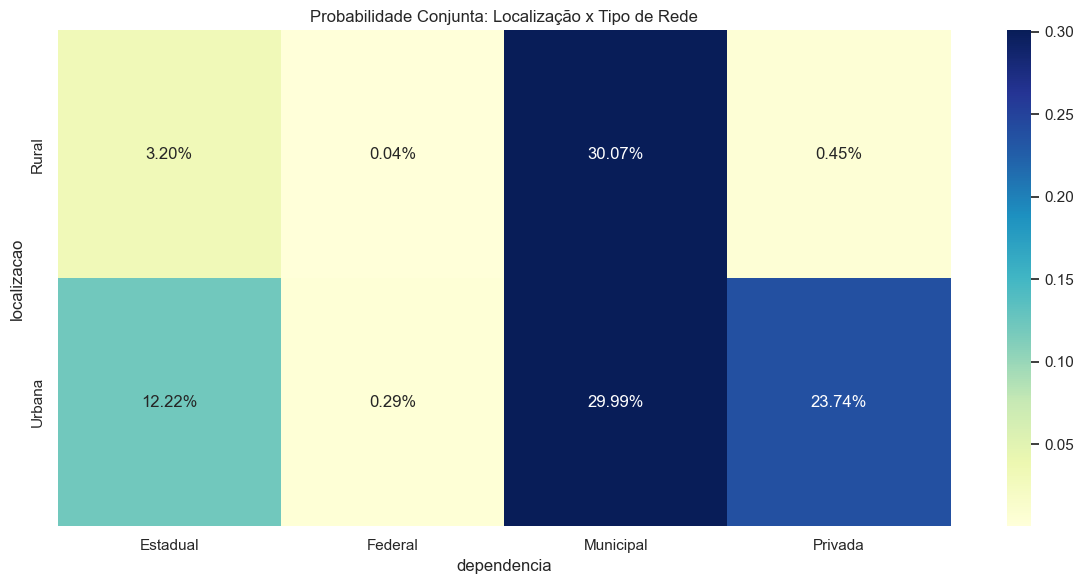

In [9]:
# 🔥 Heatmap de probabilidades conjuntas (frequência relativa)
tabela_conjunta = pd.crosstab(df['localizacao'], df['dependencia'], normalize='all')
sns.heatmap(tabela_conjunta, annot=True, cmap='YlGnBu', fmt='.2%')
plt.title('Probabilidade Conjunta: Localização x Tipo de Rede')
plt.tight_layout()
plt.show()

## 🧠 Eventos com base em faixas de matrícula

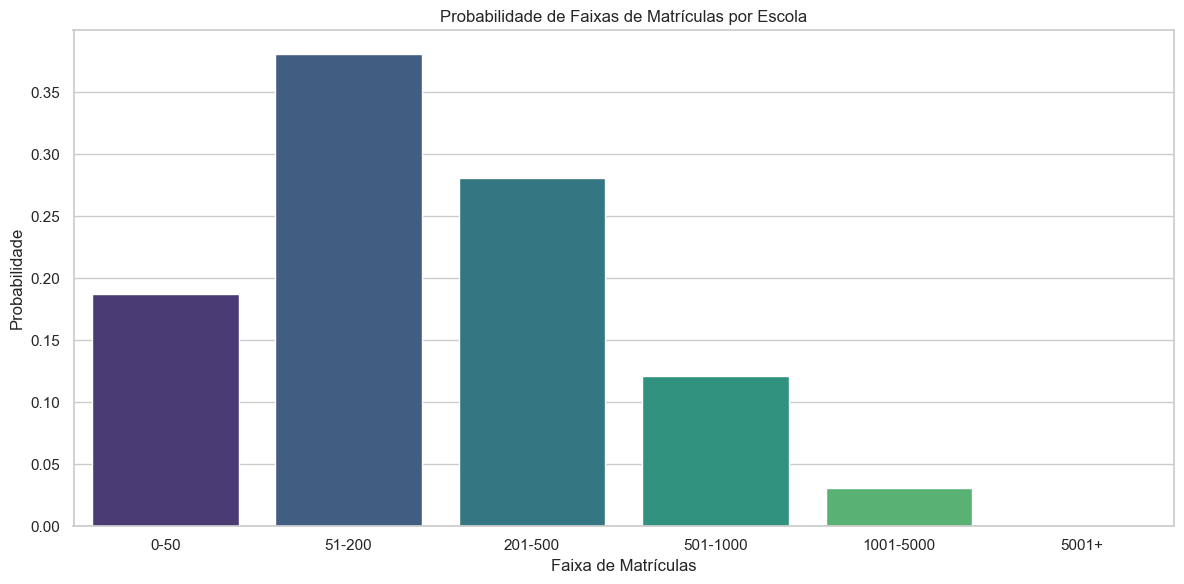

In [10]:
# Criar categorias de matrícula (faixas)
df['faixa_matriculas'] = pd.cut(df['matriculas'], bins=[0, 50, 200, 500, 1000, 5000, float('inf')],
                                 labels=['0-50', '51-200', '201-500', '501-1000', '1001-5000', '5001+'])
dist_faixa = df['faixa_matriculas'].value_counts(normalize=True).sort_index()
sns.barplot(x=dist_faixa.index, y=dist_faixa.values, palette='viridis')
plt.title('Probabilidade de Faixas de Matrículas por Escola')
plt.xlabel('Faixa de Matrículas')
plt.ylabel('Probabilidade')
plt.tight_layout()
plt.show()